In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss


In [4]:
best_rf = joblib.load("best_random_forest.pkl")

X = joblib.load("X_full.pkl")
y = joblib.load("y_full.pkl")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [5]:
y_proba = best_rf.predict_proba(X_test)[:, 1]


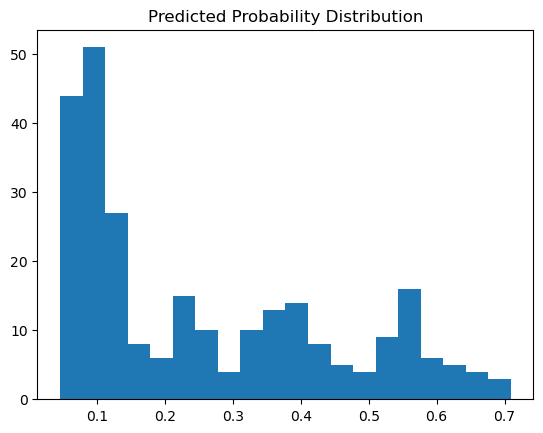

In [6]:
plt.hist(y_proba, bins=20)
plt.title("Predicted Probability Distribution")
plt.show()


###  The model is somewhat cautious in separating the positive class. This is because the graph shows variability values ​​between 0.8 and 0.9. Furthermore, the graph indicates that the model classifies most samples as belonging to class 0.


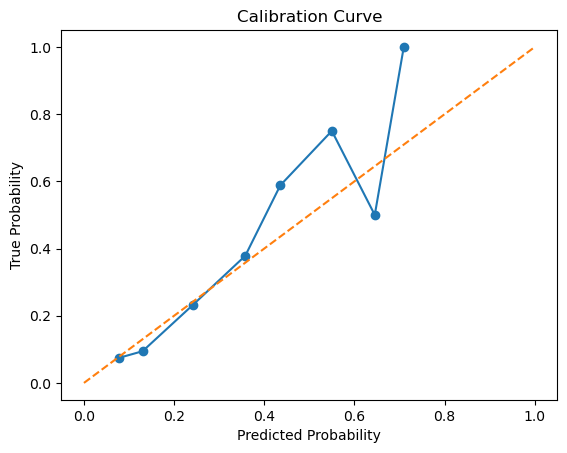

In [7]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()


### The calibration curve indicates that the model is reasonably well-calibrated at lower probability ranges but shows deviations in mid-range probabilities. While class ranking performance (AUC=0.81) is strong, probability estimates are not perfectly aligned with observed frequencies.

In [8]:
brier_score_loss(y_test, y_proba)


0.15056178196865055

In [9]:
calibrated_rf = CalibratedClassifierCV(
    best_rf,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

y_proba_cal = calibrated_rf.predict_proba(X_test)[:,1]


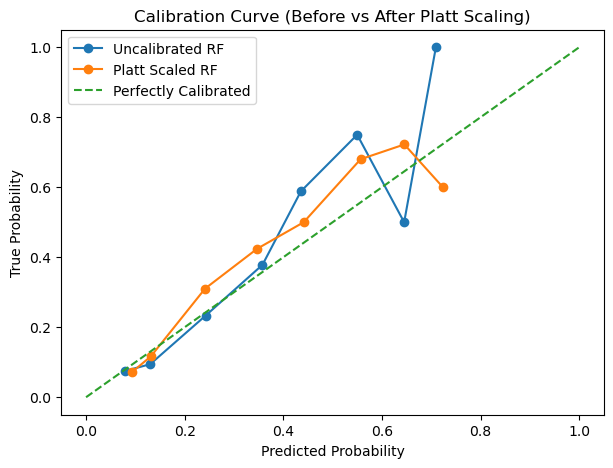

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Eski (uncalibrated) olasılıklar
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, y_proba, n_bins=10)

# Yeni (Platt scaled) olasılıklar
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(7,5))

# Orijinal model
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label="Uncalibrated RF")

# Platt scaling sonrası
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Platt Scaled RF")

# Perfect calibration çizgisi
plt.plot([0,1], [0,1], "--", label="Perfectly Calibrated")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (Before vs After Platt Scaling)")
plt.legend()
plt.show()


### After applying Platt scaling, the calibration curve moved closer to the diagonal reference line, indicating improved probability calibration. While the ranking performance (AUC ≈ 0.81) was already strong, probability estimates were not perfectly aligned with observed frequencies. Sigmoid calibration reduced mid-range deviations and improved probability reliability without significantly affecting classification performance.

In [13]:
import joblib

joblib.dump(calibrated_rf, "calibrated_rf.pkl")


['calibrated_rf.pkl']